# Task 4 – Noise and Filtering

## Objective

The objective of this task is to study how different image filtering techniques remove Gaussian noise while preserving the important details of a document image.

### Prediction

I predict that the **Bilateral Filter** will preserve the text edges the best because it smooths similar pixel intensities while maintaining sharp edges. This makes it well suited for document images where preserving character boundaries is important.

The Mean and Gaussian filters are expected to blur the text slightly, while the Median filter is generally more effective for salt-and-pepper noise than Gaussian noise.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
image = cv2.imread("raw-captures/page.jpg")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image)

[[[209 205 193]
  [208 204 192]
  [208 204 192]
  ...
  [255 246 247]
  [255 249 250]
  [255 248 249]]

 [[207 203 191]
  [208 204 192]
  [208 204 192]
  ...
  [255 246 247]
  [255 249 250]
  [255 248 249]]

 [[207 203 191]
  [208 204 192]
  [208 204 192]
  ...
  [255 246 247]
  [255 249 250]
  [255 248 249]]

 ...

 [[ 47  44  37]
  [ 45  42  35]
  [ 43  40  33]
  ...
  [106  79  62]
  [109  82  65]
  [112  85  68]]

 [[ 40  37  30]
  [ 41  38  31]
  [ 41  38  31]
  ...
  [110  83  66]
  [110  83  66]
  [111  84  67]]

 [[ 42  39  32]
  [ 43  40  33]
  [ 42  39  32]
  ...
  [111  84  67]
  [110  83  66]
  [110  83  66]]]


In [38]:
mean = 0
sigma = 50

noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)

noisy = image.astype(np.float32) + noise

noisy = np.clip(noisy, 0, 255).astype(np.uint8)

## Applying Different Filters

The noisy image is processed using four filtering techniques:

1. Mean Filter
2. Gaussian Filter
3. Median Filter
4. Bilateral Filter

Each filter removes noise differently and affects the sharpness of the document text.

In [40]:
mean_filter = cv2.blur(noisy, (5,5))

gaussian_filter = cv2.GaussianBlur(noisy, (5,5), 0)

median_filter = cv2.medianBlur(noisy, 5)

bilateral_filter = cv2.bilateralFilter(
    noisy,
    d=9,
    sigmaColor=75,
    sigmaSpace=75
)

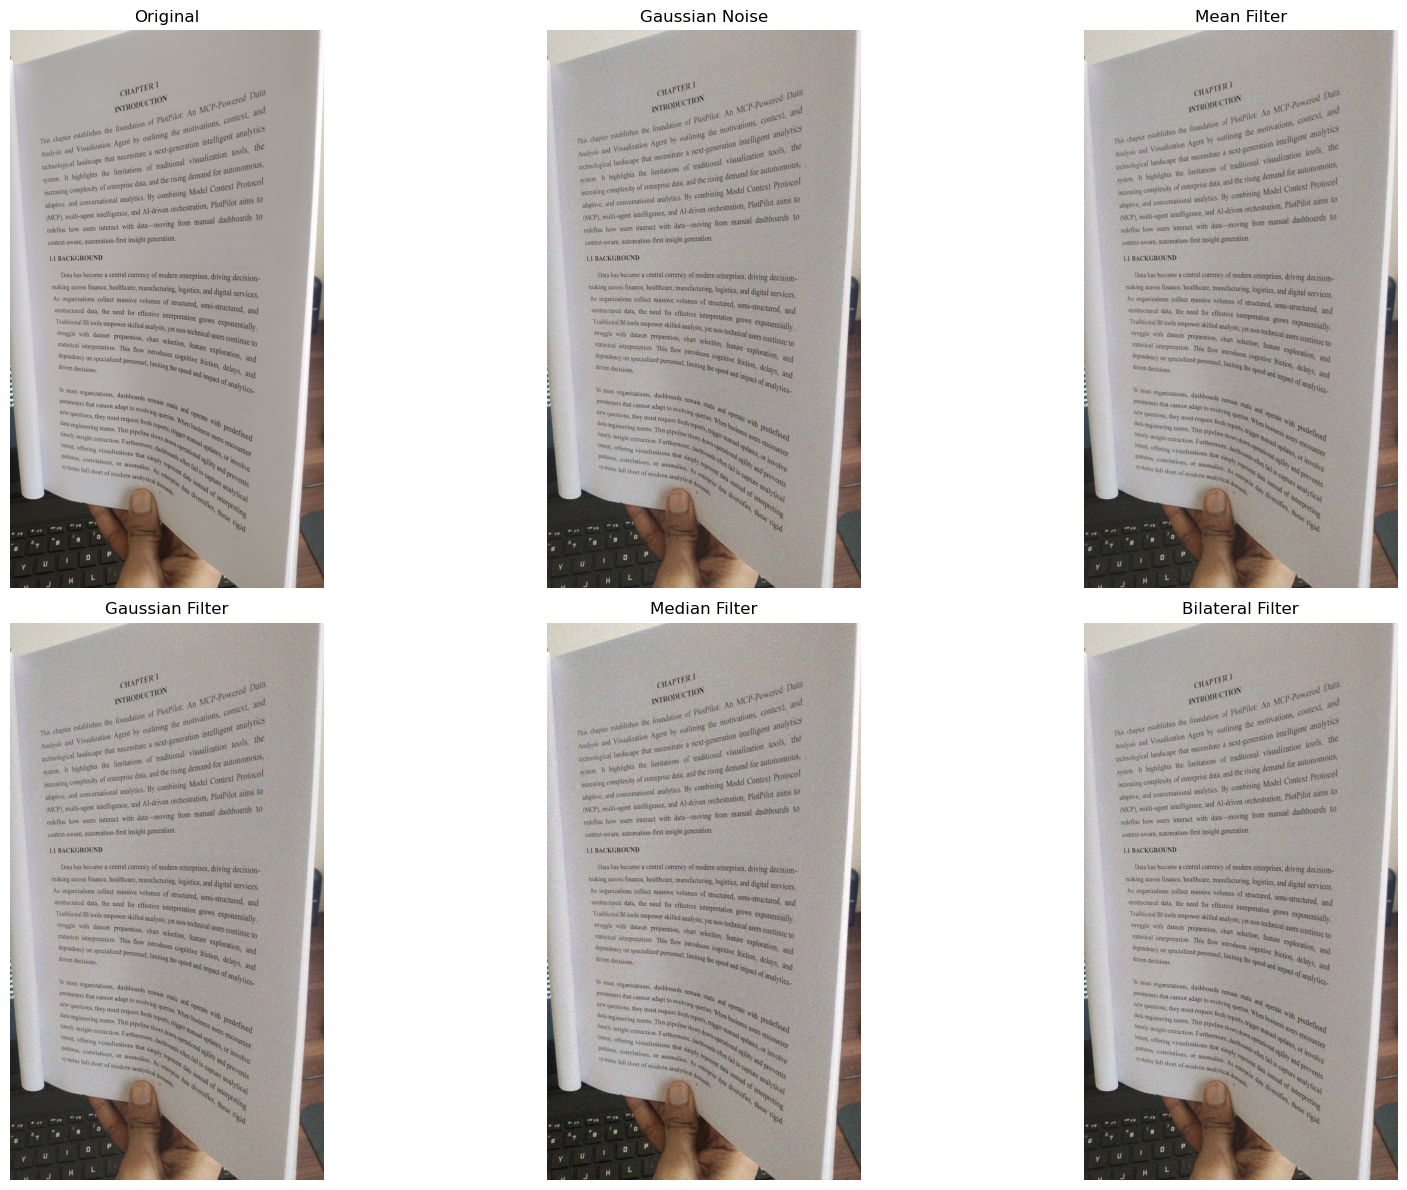

In [41]:
titles = [
    "Original",
    "Gaussian Noise",
    "Mean Filter",
    "Gaussian Filter",
    "Median Filter",
    "Bilateral Filter"
]

images = [
    image,
    noisy,
    mean_filter,
    gaussian_filter,
    median_filter,
    bilateral_filter
]

plt.figure(figsize=(18,12))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

uint8
uint8


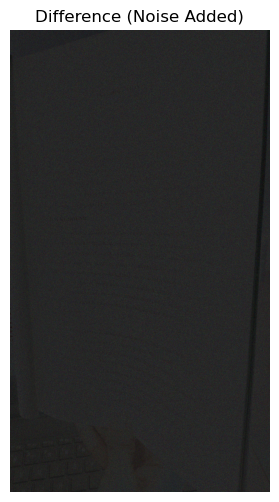

In [44]:
print(image.dtype)
print(noisy.dtype)

difference = cv2.absdiff(image, noisy)

plt.figure(figsize=(6,6))
plt.imshow(difference)
plt.title("Difference (Noise Added)")
plt.axis("off")
plt.show()

## Observations

### Mean Filter

The Mean Filter reduced the noise but blurred the text edges noticeably. Small characters became less sharp because the filter averages neighboring pixel values.

### Gaussian Filter

The Gaussian Filter removed Gaussian noise more naturally than the Mean Filter. However, some blurring of text edges was still observed.

### Median Filter

The Median Filter preserved the text better than the Mean Filter but was less effective for Gaussian noise because it is primarily designed for salt-and-pepper noise.

### Bilateral Filter

The Bilateral Filter preserved the text edges while reducing much of the noise. The characters remained sharper compared to the other filters.

### Conclusion

The prediction was correct. The Bilateral Filter produced the best balance between noise reduction and edge preservation for this document image.